# Advanced EDA: Seller Performance Analysis

In this notebook, we'll perform an in-depth analysis of the sellers on the Olist platform. The goal is to identify top performers, understand the characteristics of a "good" seller, and flag potential underperformers. We'll answer questions like:
* Who are the top sellers by revenue and order volume?
* What is the relationship between a seller's popularity and their average review score?
* How does shipping speed vary between sellers?

## 1. Creating a Seller-Level Summary

Our `master_dataset.csv` is at the order-item level. To analyze sellers, we first need to aggregate this data to create one row per seller, summarizing their key performance metrics.

In [1]:
import pandas as pd
import numpy as np
import sys
import os

# Add the project's root directory to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.plotting_utils import plot_bar, plot_scatterplot

# Load the processed master dataset
processed_data_path = '../data/processed/master_dataset.csv'
master_df = pd.read_csv(processed_data_path)

# Convert date columns back to datetime, as they are read as strings from CSV
date_columns = ['order_purchase_timestamp', 'order_delivered_customer_date']
for col in date_columns:
    master_df[col] = pd.to_datetime(master_df[col], errors='coerce')

# --- Feature Engineering at the Seller Level ---

# Calculate actual delivery time for delivered orders
delivered_df = master_df[master_df['order_status'] == 'delivered'].copy()
delivered_df['actual_delivery_time'] = (delivered_df['order_delivered_customer_date'] - delivered_df['order_purchase_timestamp']).dt.days

# Aggregate all metrics by seller_id
seller_df = delivered_df.groupby('seller_id').agg(
    total_revenue=('payment_value', 'sum'),
    num_orders=('order_id', 'nunique'),
    avg_review_score=('review_score', 'mean'),
    avg_delivery_time=('actual_delivery_time', 'mean'),
    num_products=('product_id', 'nunique')
).reset_index()

print("Seller summary DataFrame created.")
seller_df.head()

Seller summary DataFrame created.


,seller_id,total_revenue,num_orders,avg_review_score,avg_delivery_time,num_products
0,0015a82c2db000af6aaaf3ae2ecb0532,2748.06,3,3.666667,10.333333,1
1,001cca7ae9ae17fb1caed9dfb1094831,47557.95,195,3.974249,12.605932,11
2,002100f778ceb8431b7a1020ff7ab48f,2445.33,50,4.086207,15.482759,24
3,003554e2dce176b5555353e4f3555ac8,139.38,1,5.000000,4.000000,1
4,004c9cd9d87a3c30c522c48c4fc07416,28502.65,156,4.122549,13.815534,87


## 2. Identifying Top Sellers

Let's start by identifying the marketplace superstars—the sellers who generate the most revenue and handle the most orders.

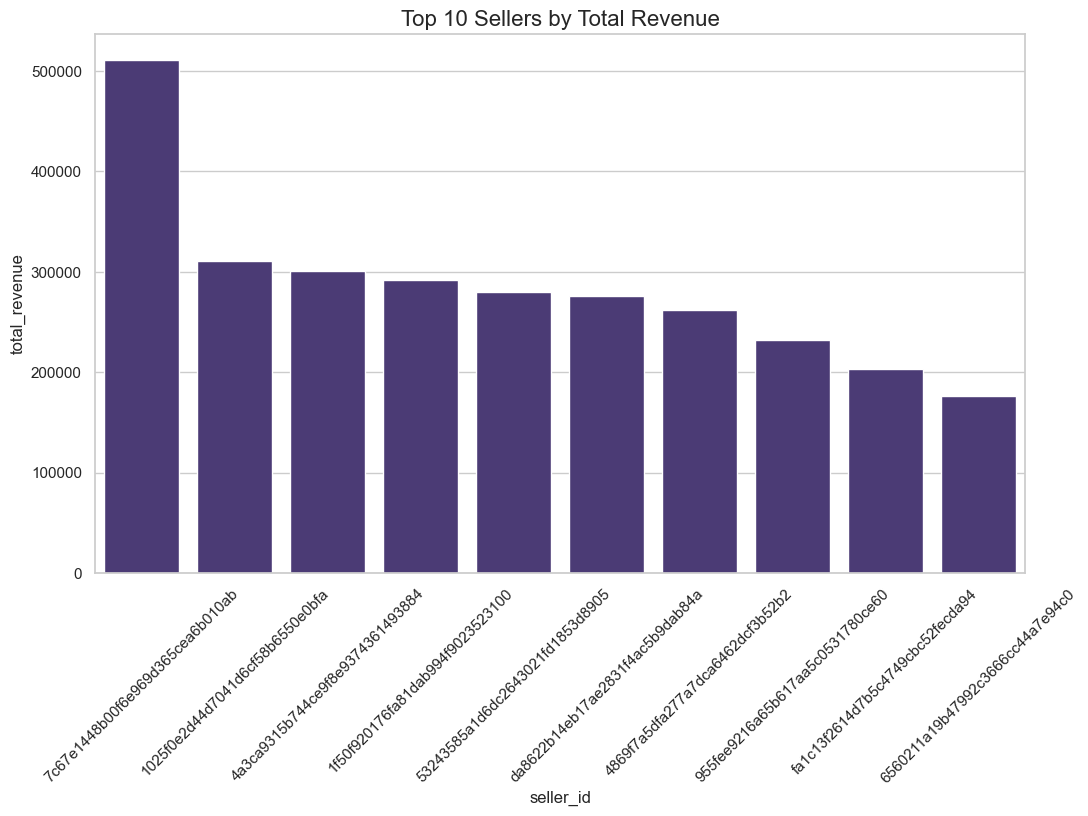

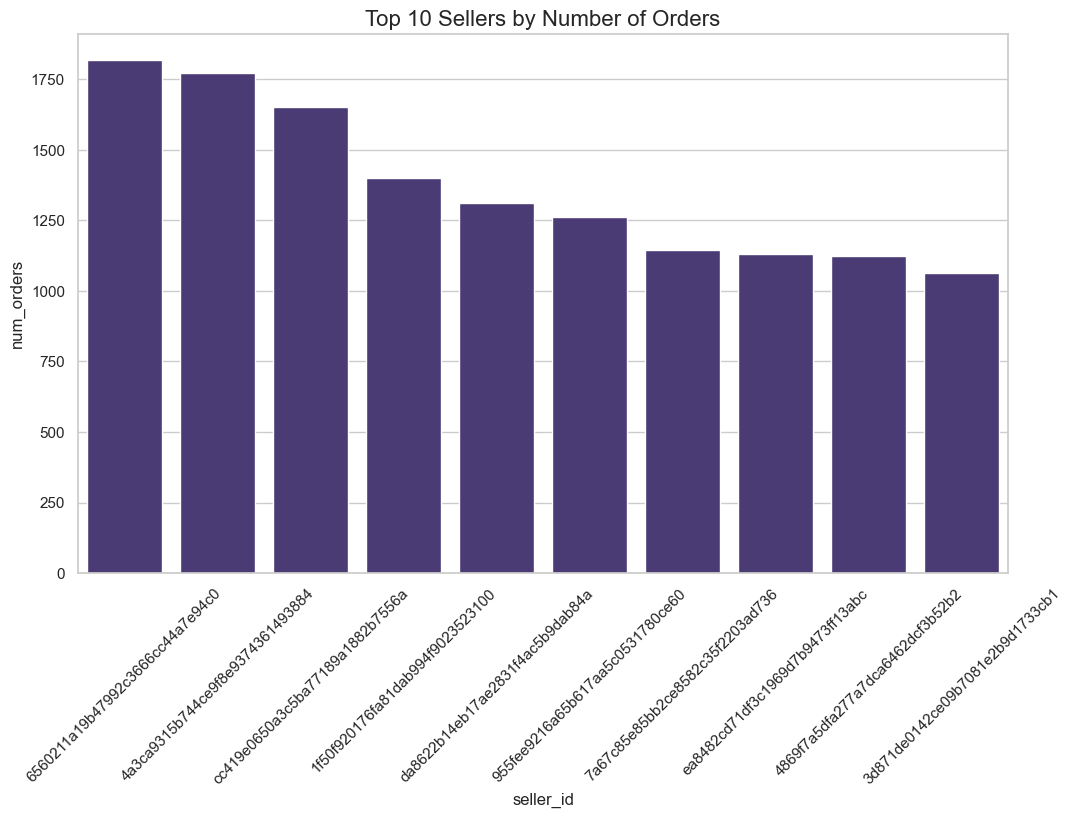

In [2]:
# Top 10 sellers by total revenue
top_revenue_sellers = seller_df.sort_values(by='total_revenue', ascending=False)
plot_bar(
    data=top_revenue_sellers,
    x_col='seller_id',
    y_col='total_revenue',
    title='Top 10 Sellers by Total Revenue',
    top_n=10
)

# Top 10 sellers by number of orders
top_orders_sellers = seller_df.sort_values(by='num_orders', ascending=False)
plot_bar(
    data=top_orders_sellers,
    x_col='seller_id',
    y_col='num_orders',
    title='Top 10 Sellers by Number of Orders',
    top_n=10
)

## 3. Analyzing Seller Quality vs. Quantity

Are the most popular sellers also the best ones? Let's create a scatter plot to see the relationship between the number of orders a seller has and their average review score. This can help us identify sellers who maintain high quality at scale, as well as popular sellers who might be struggling with customer satisfaction.

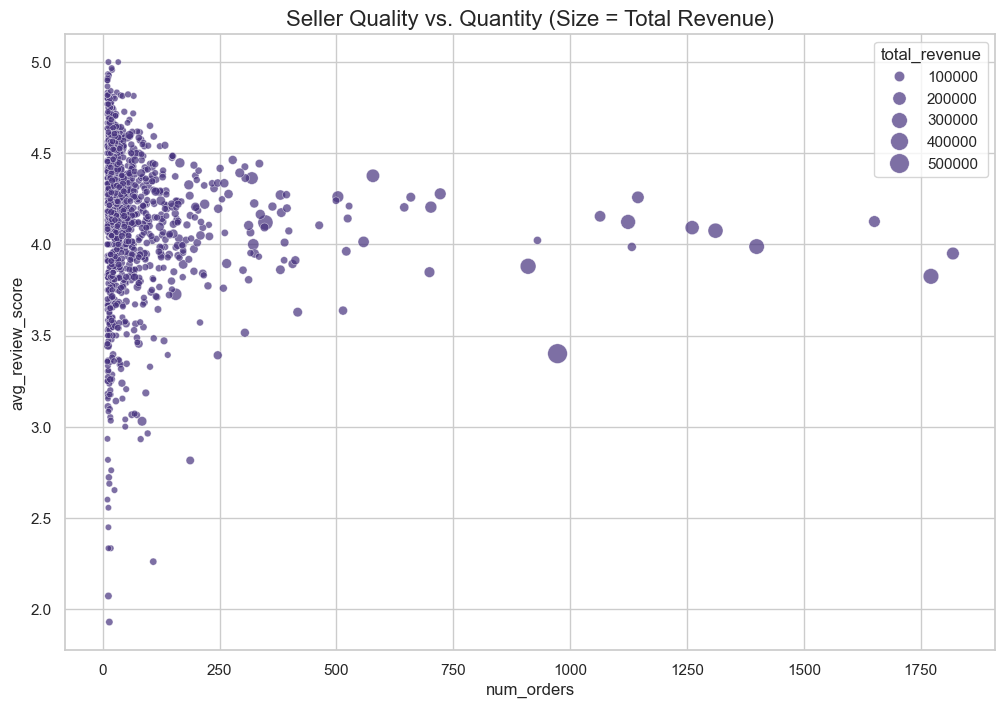

In [3]:
# To make the plot readable, we'll filter out sellers with very few orders (e.g., less than 10)
sellers_with_min_orders = seller_df[seller_df['num_orders'] >= 10]

# After updating the function:
plot_scatterplot(
    data=sellers_with_min_orders,
    x_col='num_orders',
    y_col='avg_review_score',
    size_col='total_revenue',
    title='Seller Quality vs. Quantity (Size = Total Revenue)'
)

## Advanced EDA: NLP on Customer Reviews

In this section, we'll analyze the text data from customer reviews to understand the reasons for their ratings. We will focus on the most extreme cases: 1-star (worst) and 5-star (best) reviews. Our goal is to answer:
* What are the most common words used in negative reviews?
* What are the most common words used in positive reviews?
* Can we automatically discover the main topics of complaints and praise using Topic Modeling?

### 1. Data Preparation and Text Preprocessing

First, we need to prepare the text data for analysis. This involves creating two separate datasets (for 1-star and 5-star reviews), cleaning the text by removing punctuation, and filtering out common "stopwords" (like "a", "o", "e" in Portuguese) that don't carry much meaning.

In [4]:
import re
from nltk.corpus import stopwords

# --- Prepare the Datasets ---
# Filter for 1-star and 5-star reviews that have a comment message
reviews_1_star = master_df[(master_df['review_score'] == 1) & (master_df['review_comment_message'].notna())].copy()
reviews_5_star = master_df[(master_df['review_score'] == 5) & (master_df['review_comment_message'].notna())].copy()

# --- Text Preprocessing Function ---
stop_words = set(stopwords.words('portuguese'))

def preprocess_text(text):
    """Cleans and prepares text for NLP analysis."""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove stopwords
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

# Apply the preprocessing
reviews_1_star['cleaned_comment'] = reviews_1_star['review_comment_message'].apply(preprocess_text)
reviews_5_star['cleaned_comment'] = reviews_5_star['review_comment_message'].apply(preprocess_text)

print("Text preprocessing complete.")

Text preprocessing complete.


### 2. Visualizing with Word Clouds

A word cloud is a simple but powerful way to visualize word frequency. The larger the word, the more often it appears in the text. This will give us an immediate visual sense of the key terms in negative versus positive reviews.

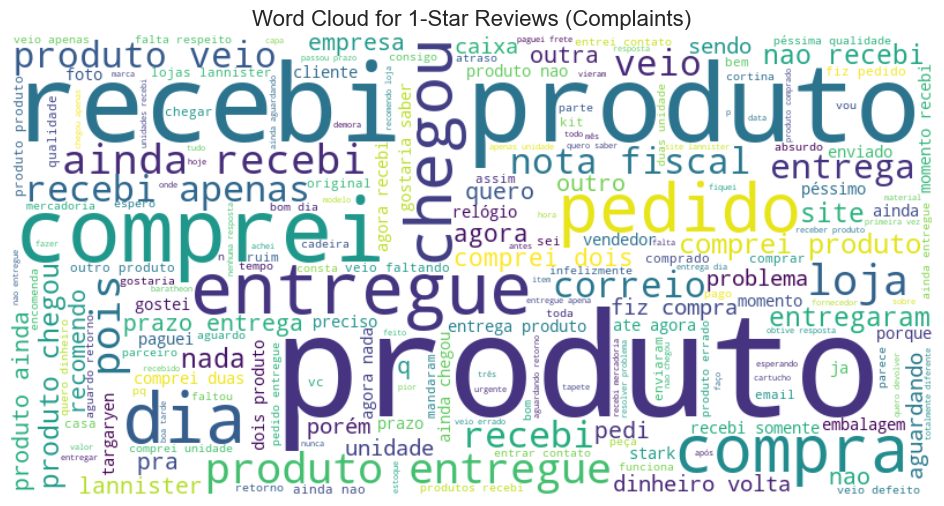

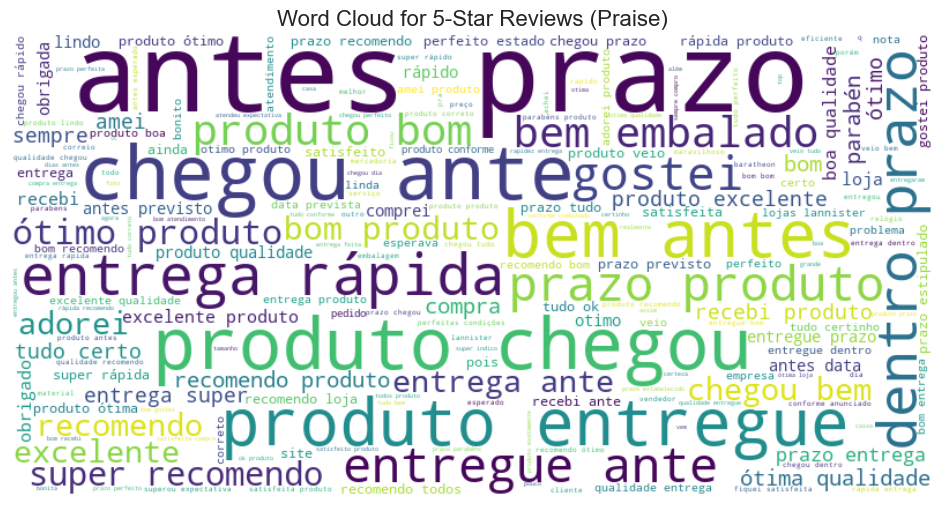

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- Word Cloud for 1-Star Reviews ---
text_1_star = ' '.join(reviews_1_star['cleaned_comment'])
wordcloud_1_star = WordCloud(width=800, height=400, background_color='white').generate(text_1_star)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_1_star, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for 1-Star Reviews (Complaints)', fontsize=16)
plt.show()

# --- Word Cloud for 5-Star Reviews ---
text_5_star = ' '.join(reviews_5_star['cleaned_comment'])
wordcloud_5_star = WordCloud(width=800, height=400, background_color='white').generate(text_5_star)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_5_star, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for 5-Star Reviews (Praise)', fontsize=16)
plt.show()

### 3. Discovering Themes with Topic Modeling (LDA)

While word clouds show single words, **Topic Modeling** is a more advanced technique that can find clusters of words that represent underlying themes or topics. We'll use Latent Dirichlet Allocation (LDA) to find the top 5 complaint topics and the top 5 praise topics.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

def find_topics(text_data, num_topics=5, num_words=10):
    """Performs LDA Topic Modeling and prints the top words for each topic."""
    # Create a document-term matrix
    # We convert the set of stopwords to a list, as required by CountVectorizer
    vectorizer = CountVectorizer(max_df=0.9, min_df=25, stop_words=list(stop_words)) # <-- This is the corrected line
    doc_term_matrix = vectorizer.fit_transform(text_data)
    
    # Run the LDA model
    lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
    lda.fit(doc_term_matrix)
    
    # Print the topics
    feature_names = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(lda.components_):
        print(f"Topic #{topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]))
    print("-" * 20)

# --- Find Complaint Topics ---
print("Top 5 Complaint Topics (from 1-Star Reviews):")
find_topics(reviews_1_star['cleaned_comment'])

# --- Find Praise Topics ---
print("Top 5 Praise Topics (from 5-Star Reviews):")
find_topics(reviews_5_star['cleaned_comment'])

Top 5 Complaint Topics (from 1-Star Reviews):
Topic #1:
produto recebi ainda entrega prazo chegou entregue nao dia dias
Topic #2:
recebi pedido agora entregue dia contato compra fiz mercadoria nada
Topic #3:
produto veio comprei qualidade diferente errado troca cor outro defeito
Topic #4:
produto compra loja lannister entrega correios quero dinheiro frete recomendo
Topic #5:
comprei recebi apenas dois produtos nota entregue veio unidades somente
--------------------
Top 5 Praise Topics (from 5-Star Reviews):
Topic #1:
qualidade produto tudo amei ótima boa otimo lindo ok adorei
Topic #2:
produto excelente ótimo recomendo loja compra rápido satisfeita super qualidade
Topic #3:
entrega recomendo rápida super sempre parabéns produto lannister loja produtos
Topic #4:
prazo antes produto chegou bem entregue entrega recebi previsto perfeito
Topic #5:
bom produto gostei dentro tudo conforme recomendo veio comprar bem
--------------------


## Advanced EDA: Customer Retention with Cohort Analysis

This is the final and most advanced part of our EDA. We know from our earlier analysis that customer retention is very low. A cohort analysis will give us a much more nuanced view of this problem by tracking groups of customers (cohorts) over time.

A cohort is a group of customers who made their first-ever purchase in the same month. We will track each cohort and see what percentage of them return in the following months. This will help us answer:
* How sticky is our platform for new customers?
* Has our ability to retain customers improved or worsened over time?

### 1. Preparing the Cohort Data

This is the most complex data manipulation step. We need to calculate three things for each order:
1.  The customer's unique ID.
2.  The month of the current purchase.
3.  The "cohort month" (the month of that customer's *very first* purchase).

In [8]:
# Ensure date columns are in datetime format
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])

# Create an 'order_month' column by truncating the timestamp to the start of the month
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

# Create the 'cohort' column: the month of each customer's first purchase
master_df['cohort'] = master_df.groupby('customer_unique_id')['order_purchase_timestamp'] \
                               .transform('min') \
                               .dt.to_period('M')

# Calculate the cohort index: the number of months since the first purchase
# We need to work with integers for this calculation
cohort_data = master_df.groupby(['cohort', 'order_month'])['customer_unique_id'].nunique().reset_index()

# Convert Period objects to integers for subtraction
cohort_data['cohort_period'] = cohort_data['cohort'].apply(lambda x: x.start_time.month + x.start_time.year * 12)
cohort_data['order_period'] = cohort_data['order_month'].apply(lambda x: x.start_time.month + x.start_time.year * 12)
cohort_data['cohort_index'] = cohort_data['order_period'] - cohort_data['cohort_period']

# Create the final cohort pivot table
cohort_pivot = cohort_data.pivot_table(index='cohort',
                                     columns='cohort_index',
                                     values='customer_unique_id')

print("Cohort data prepared.")
cohort_pivot.head()

Cohort data prepared.


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


### 2. Calculating the Retention Rate

The pivot table above shows the absolute number of customers from each cohort who returned in subsequent months. It's more intuitive to express this as a percentage of the original cohort size.

In [9]:
# Get the size of each cohort (the number of new customers in that month)
cohort_size = cohort_pivot.iloc[:, 0]

# Divide the number of returning customers by the cohort size to get the retention rate
cohort_retention = cohort_pivot.divide(cohort_size, axis=0)

# Format as a percentage
cohort_retention = cohort_retention.round(4) * 100

print("Cohort retention rates calculated.")
cohort_retention.head()

Cohort retention rates calculated.


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.31,NaN,NaN,0.31,NaN,0.31,NaN,0.31,NaN,0.31,NaN,0.31,0.62,0.62
2016-12,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.39,0.26,0.13,0.39,0.13,0.52,0.13,0.13,NaN,0.39,0.13,0.79,0.39,0.13,0.13,0.26,0.39,0.13,NaN
2017-02,100.0,0.23,0.29,0.11,0.40,0.11,0.23,0.17,0.17,0.23,0.11,0.29,0.17,0.17,0.11,0.06,0.06,0.23,NaN,NaN


### 3. Visualizing the Retention Heatmap

Now we can visualize the retention table as a heatmap. This provides an instant, at-a-glance view of customer loyalty over time.

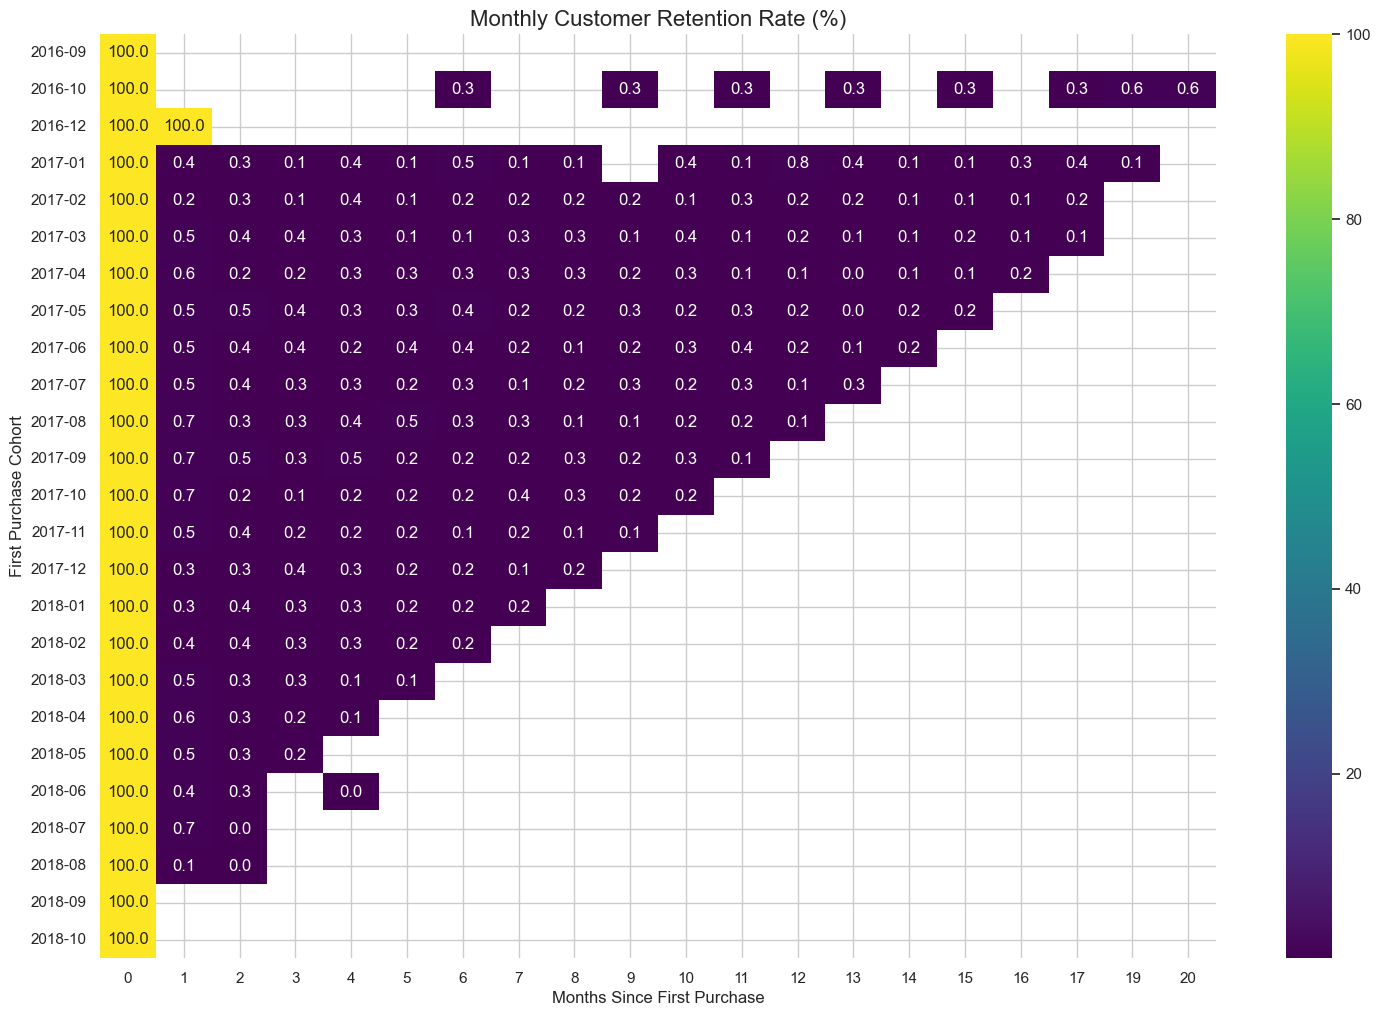

In [11]:
# --- Visualization ---
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 12))
sns.heatmap(
    data=cohort_retention,
    annot=True,
    fmt='.1f', # Format annotations to one decimal place
    cmap='viridis'
)
plt.title('Monthly Customer Retention Rate (%)', fontsize=16)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('First Purchase Cohort', fontsize=12)
plt.show()